# Install Required Packages

In [1]:
!apt-get install libncurses5

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libtinfo5
The following NEW packages will be installed:
  libncurses5 libtinfo5
0 upgraded, 2 newly installed, 0 to remove and 45 not upgraded.
Need to get 207 kB of archives.
After this operation, 883 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libtinfo5 amd64 6.3-2ubuntu0.1 [100 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libncurses5 amd64 6.3-2ubuntu0.1 [107 kB]
Fetched 207 kB in 0s (1,969 kB/s)
Selecting previously unselected package libtinfo5:amd64.
(Reading database ... 121913 files and directories currently installed.)
Preparing to unpack .../libtinfo5_6.3-2ubuntu0.1_amd64.deb ...
Unpacking libtinfo5:amd64 (6.3-2ubuntu0.1) ...
Selecting previously unselected package libncurses5:amd64.
Preparing to unpack .../libncurses5_6.3-2ubuntu0.1_am

In [5]:
!pip install import-ipynb seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.5 MB/s eta 0:00:00


---
# Import Packages

In [2]:
# Google Drive
from google.colab import drive
drive.mount("mnt", force_remount=True)

# Data Cleaning
from datetime import datetime, timedelta
import json
import os
import numpy as np
import pandas as pd

# Modelling
from sklearn.preprocessing import MinMaxScaler

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d

Mounted at mnt


In [3]:
%cd "mnt/Shareddrives/ECIS2024_CM"

/content/mnt/Shareddrives/ECIS2024_CM


In [6]:
# Import Functions from Other NB
import import_ipynb
from ContagionModels_Utils import noOutlier, emotionGroup, describeEvent, plotLine, plotStack

importing Jupyter notebook from ContagionModels_Utils.ipynb


---
# 1. Functions

In [7]:
def load_data(query):
  # Videos
  with open(f'{query}/{query}_videos.json', "r") as f:
    videos = json.loads(f.read())
  keys = list(videos['videos'][0].keys())
  df_videos = pd.DataFrame.from_dict({k:[x[k] for x in videos['videos'] if x != 'No videos'] for k in keys})

  # Stats
  with open(f'{query}/{query}_stats.json', "r") as f:
    stats = json.loads(f.read())
  keys = list(stats[0].keys())
  dict = {k:[] for k in keys}
  for k in keys:
      x = []
      for i in stats:
          try:
              dict[k].append(i[k])
          except:
              dict[k].append(np.nan)
  df_stats = pd.DataFrame.from_dict(dict)
  df_stats.fillna(0, inplace=True)
  for col in ['viewCount', 'likeCount', 'favoriteCount', 'commentCount']:
      df_stats[col] = df_stats[col].astype(int)

  # Comments
  comments = []
  for i in [x for x in os.listdir(f'{query}') if x.split('_')[1] not in ['videos.json', 'stats.json']]:
      with open(f'{query}/'+i, "r") as f:
        comments += json.loads(f.read())
  keys = list(comments[0].keys())
  df_comments = pd.DataFrame.from_dict({k:[x[k] for x in comments] for k in keys})

  return {
      'df_videos'   : df_videos,
      'df_stats'    : df_stats,
      'df_comments' : df_comments
  }

In [8]:
def transform_data(dic):

    df_videos, df_stats, df_comments = dic['df_videos'], dic['df_stats'], dic['df_comments']

    # Group emotions
    df_comments['emotionraw'] = df_comments['emotion']
    df_comments['emotion'] = df_comments['emotionraw'].apply(lambda x: emotionGroup(x))
    df_comments['valence'] = df_comments['emotionraw'].apply(lambda x: emotionGroup(x, valence=True))

    # Add dates to stats
    df_vid_stats = df_videos.merge(df_stats, how='left', left_on='videoId', right_on='id')
    df_vid_stats = noOutlier(df_vid_stats, ['viewCount', 'likeCount', 'commentCount'])

    # Describe
    desc_vid_stats = describeEvent(df_vid_stats, ['viewCount', 'likeCount', 'commentCount'])

    # Describe
    df_describe = describeEvent(df_vid_stats, ['viewCount', 'likeCount', 'commentCount'], func = ['count', 'mean', 'std', 'var', 'min', 'max', 'sum'])

    # Convert columns
    df_vid_stats['publishedAt']= pd.to_datetime(df_vid_stats['publishedAt'])
    df_vid_stats['date'] = df_vid_stats['publishedAt'].dt.date

    for col in ['viewCount', 'likeCount', 'favoriteCount', 'commentCount']:
        df_vid_stats[col] = pd.to_numeric(df_vid_stats[col])

    # Group and summarise
    df_vid_stats_date = df_vid_stats.groupby('date')\
                                    .agg(   viewSum=('viewCount', 'sum'),
                                            likeSum=('likeCount', 'sum'),
                                            favoriteSum=('favoriteCount', 'sum'),
                                            commentSum=('commentCount', 'sum'),
                                            viewAvg=('viewCount', 'mean'),
                                            likeAvg=('likeCount', 'mean'),
                                            favoriteAvg=('favoriteCount', 'mean'),
                                            commentAvg=('commentCount', 'mean'),
                                    )\
                                    .reset_index()
    # Convert columns
    df_comments['publishedAt']= pd.to_datetime(df_comments['publishedAt'])
    df_comments['date'] = df_comments['publishedAt'].dt.date

    # Restrict date range
    df_comments_T = df_comments[~df_comments['emotion'].isin(['Neutral', 'error'])].groupby('emotion').agg(count=('commentid', 'count')).sort_values(by='count', ascending=False).T

    df_emo_date = df_comments.groupby(['emotion', 'date']).agg(n=('commentid', 'count')).reset_index()
    df_emo_date_T = df_emo_date[~df_emo_date['emotion'].isin(['Neutral', 'error'])]\
                        .groupby(['emotion'])\
                        .agg( avg=('n', 'mean'),
                              sd=('n', np.std),
                              min=('n', 'min'),
                              max=('n', 'max')
                            )\
                        .reset_index()\
                        .T

    df_comments_emoclean = df_comments[~df_comments["emotion"].isin(["Neutral", "error"])]

    return {
        'df_comments'         : df_comments,
        'df_vid_stats'        : df_vid_stats,
        'desc_vid_stats'      : desc_vid_stats,
        'df_describe'         : df_describe,
        'df_vid_stats_date'   : df_vid_stats_date,
        'df_comments_T'       : df_comments_T,
        'df_emo_date'         : df_emo_date,
        'df_emo_date_T'       : df_emo_date_T,
        'df_comments_emoclean': df_comments_emoclean,
    }

In [9]:
def plotter_indiv_comparison(
    df_dict: dict,
    title: str,
    smooth: bool = True,
    legend: bool = False,
    xlabel: str = ' ',
    ylabel: str = ' ',
    width = 3.1,
    height = 2.5
    ):

    queries = list(df_dict.keys())
    scaler = MinMaxScaler()

    plt.clf()
    fig, ax = plt.subplots(layout='constrained', figsize=(width,height))

    output = {}

    for k, v in df_dict.items():
      if smooth:
        smoothed_series = gaussian_filter1d(pd.DataFrame(scaler.fit_transform(v[[title]])).squeeze(), sigma=2)
        output[k] = smoothed_series
        if k == 'FTX':
          ax.plot(np.arange(len(v['date'])), smoothed_series, '--', alpha=0.5, color='k', label=k)
        else:
          ax.plot(np.arange(len(v['date'])), smoothed_series, alpha=0.7, label=k)
      else:
          scaled_series = scaler.fit_transform(v[[title]])
          output[k] = scaled_series
          if k == 'FTX':
            ax.plot(np.arange(len(v['date'])), scaled_series, '--', alpha=0.5, color='k', label=k)
          else:
            ax.plot(np.arange(len(v['date'])), scaled_series, alpha=0.7, label=k)

    if legend:
      #fig.legend(loc='outside center right')
      fig.legend(loc='outside upper center', bbox_transform=fig.transFigure, ncol=5)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

    return output

---
# 2. Load and Transform Data

In [10]:
raw_ftx = load_data('ftx')
ftx = transform_data(raw_ftx)

In [11]:
raw_binance = load_data('binance')
binance = transform_data(raw_binance)

In [12]:
raw_coinbase = load_data('coinbase')
coinbase = transform_data(raw_coinbase)

In [13]:
raw_crypto = load_data('crypto')
crypto = transform_data(raw_crypto)

---
# 3. Initial Visualisation

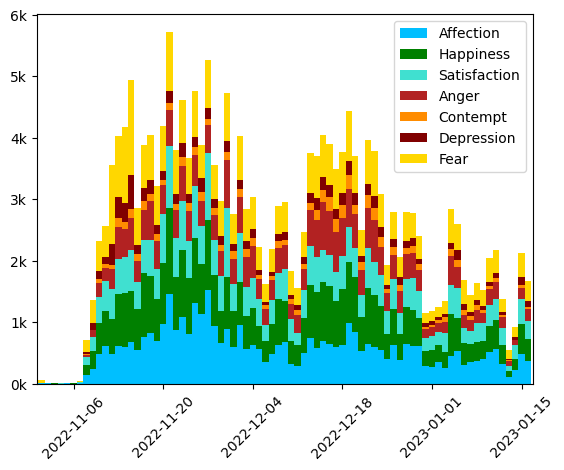

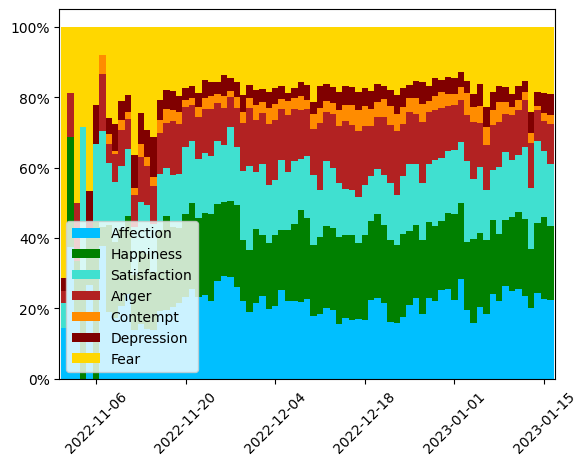

In [14]:
ftx_emotion, ftx_emotion100 = plotStack(ftx['df_comments'], ['2022-11-01', '2023-01-30'])

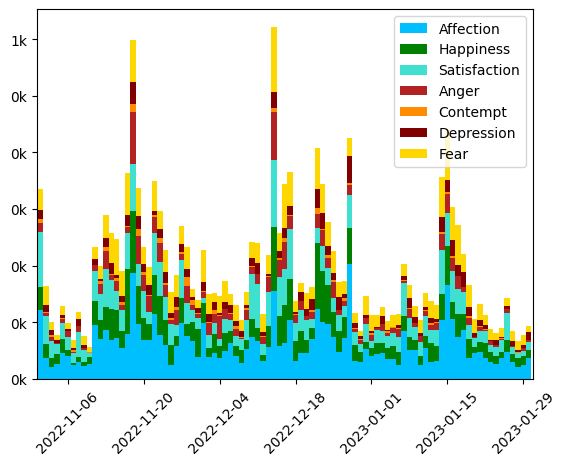

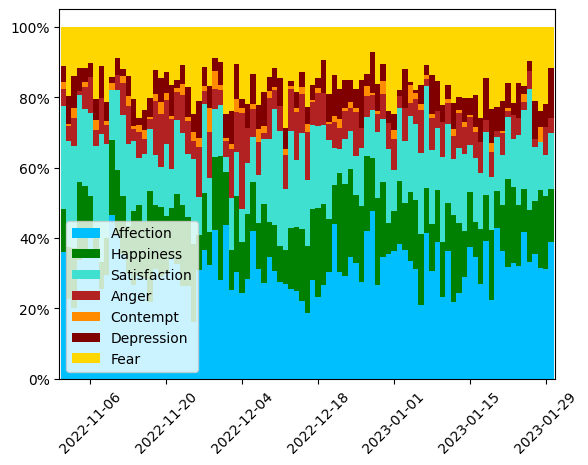

In [15]:
binance_emotion, binance_emotion100 = plotStack(binance['df_comments'], ['2022-11-01', '2023-01-30'])

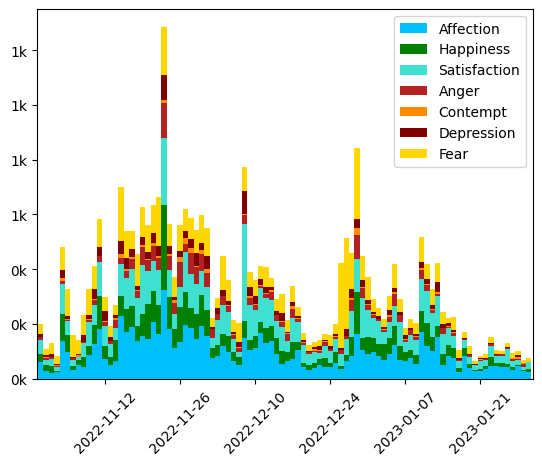

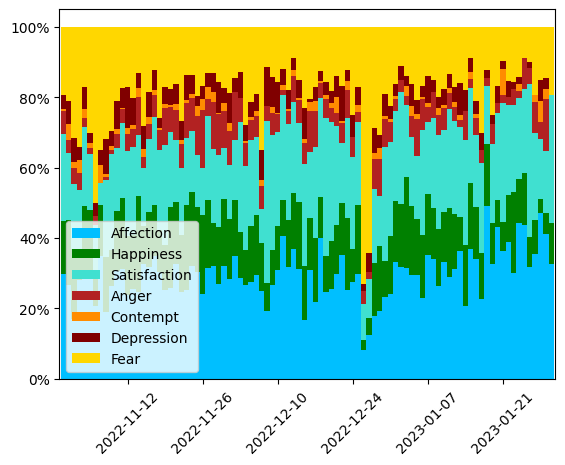

In [16]:
coinbase_emotion, coinbase_emotion100 = plotStack(coinbase['df_comments'], ['2022-10-31', '2023-01-30'])

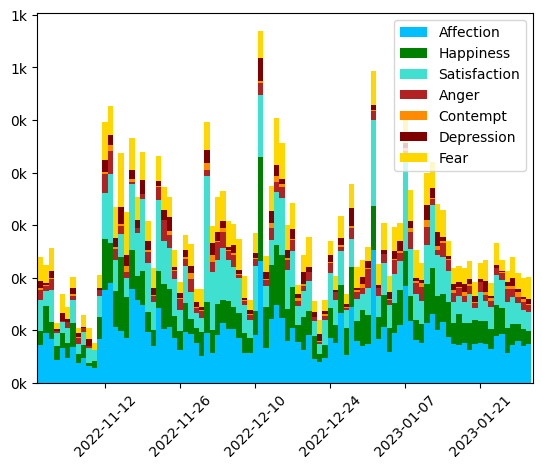

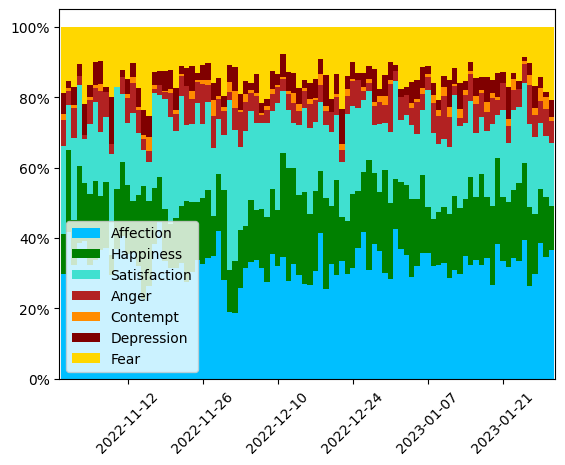

In [17]:
crypto_emotion, crypto_emotion100 = plotStack(crypto['df_comments'], ['2022-10-31', '2023-01-30'])

---
# 4. Visual Comparison

In [18]:
import datetime as dt

In [19]:
df_dict = {
    'FTX': ftx_emotion[(ftx_emotion['date']>=dt.date(2022,11,1)) & (ftx_emotion['date']<=dt.date(2023,1,16))].fillna(0),
    'Binance': binance_emotion[(binance_emotion['date']>=dt.date(2022,11,1)) & (binance_emotion['date']<=dt.date(2023,1,16))].fillna(0),
    'Coinbase': coinbase_emotion[(coinbase_emotion['date']>=dt.date(2022,11,1)) & (coinbase_emotion['date']<=dt.date(2023,1,16))].fillna(0),
    'Market': crypto_emotion[(crypto_emotion['date']>=dt.date(2022,11,1)) & (crypto_emotion['date']<=dt.date(2023,1,16))].fillna(0),
}

<Figure size 640x480 with 0 Axes>

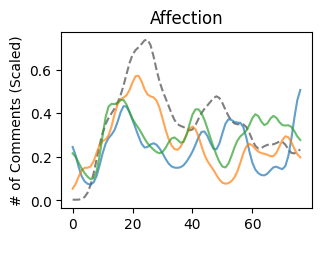

In [20]:
affection_dict = plotter_indiv_comparison(df_dict, title='Affection', ylabel='# of Comments (Scaled)')

<Figure size 640x480 with 0 Axes>

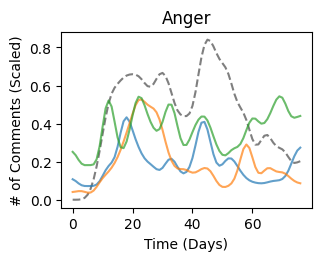

In [21]:
anger_dict = plotter_indiv_comparison(df_dict, title='Anger', ylabel = '# of Comments (Scaled)', xlabel = 'Time (Days)')

<Figure size 640x480 with 0 Axes>

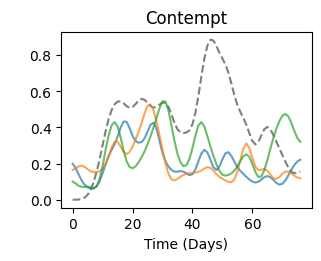

In [22]:
contempt_dict = plotter_indiv_comparison(df_dict, title='Contempt', xlabel = 'Time (Days)')

<Figure size 640x480 with 0 Axes>

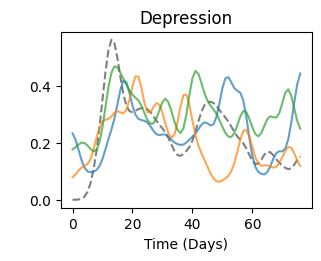

In [23]:
depression_dict = plotter_indiv_comparison(df_dict, title='Depression', xlabel = 'Time (Days)')

<Figure size 640x480 with 0 Axes>

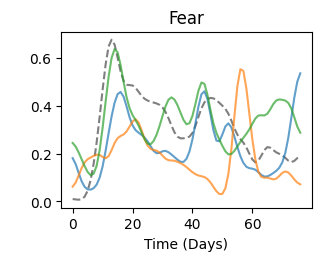

In [24]:
fear_dict = plotter_indiv_comparison(df_dict, title='Fear', xlabel = 'Time (Days)')

<Figure size 640x480 with 0 Axes>

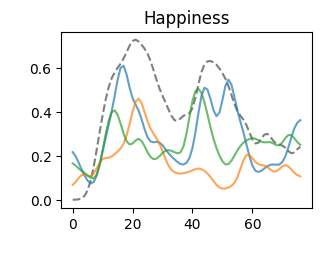

In [25]:
happiness_dict = plotter_indiv_comparison(df_dict, title='Happiness')

<Figure size 640x480 with 0 Axes>

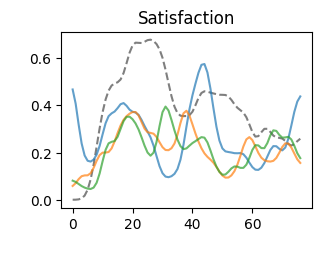

In [26]:
satisfaction_dict = plotter_indiv_comparison(df_dict, title='Satisfaction')

# 5. Correlations

## 5.1 Peaks

In [27]:
from scipy import signal
emo_dict = fear_dict
target = 'Market'
n = len(affection_dict['FTX'])

In [28]:
import scipy
print(scipy.stats.pearsonr(emo_dict['FTX'], emo_dict[target]))
print(scipy.stats.spearmanr(emo_dict['FTX'], emo_dict[target]))
print(scipy.stats.kendalltau(emo_dict['FTX'], emo_dict[target]))

PearsonRResult(statistic=0.5372571411902061, pvalue=4.710405445024492e-07)
SignificanceResult(statistic=0.3791997476208002, pvalue=0.0006713885612888671)
SignificanceResult(statistic=0.2727272727272727, pvalue=0.0004483613666970619)


In [29]:
import statsmodels.api as sm

statsmodels_correlation = sm.OLS(emo_dict['FTX'], emo_dict[target]).fit().rsquared
print('Statsmodels Correlation:', statsmodels_correlation)

Statsmodels Correlation: 0.8558754900865527


In [30]:
series1 = pd.DataFrame(emo_dict['FTX'])[0]
series2 = pd.DataFrame(emo_dict[target])[0]
lags = np.arange(-(30), (30), 1)
rs = np.nan_to_num([pd.Series(emo_dict['FTX']).corr(pd.Series(emo_dict[target]).shift(lag)) for lag in lags])

print(f"""xcorr
lag: {lags[np.argmax(rs)]}
value: {np.max(rs)}""")

xcorr
lag: -1
value: 0.5568450662678562


In [31]:
l_emotions = ['Affection', 'Anger', 'Contempt', 'Depression', 'Fear', 'Happiness', 'Satisfaction']
l_emodicts = [affection_dict, anger_dict, contempt_dict, depression_dict, fear_dict, happiness_dict, satisfaction_dict]
smoothed_dict = {e: {k: v for k,v in d.items()} for e,d in zip(l_emotions, l_emodicts)}

n_start = 3
n_end = n_start+21+1
smoothed_ndays_dict = {e: {k: v[n_start:n_end] for k,v in d.items()} for e,d in zip(l_emotions, l_emodicts)}

In [32]:
def corrplot(
    smoothed_dict: dict,
    legend: bool = False,
    title: str = ' ',
    xlabel: str = ' ',
    ylabel: str = ' ',
    width = 3.1,
    height = 2.5
    ):
    plt.clf()

    fig, ax = plt.subplots(layout='constrained', figsize=(width,height))

    # Convert to series
    series_dict = {k: pd.Series(v) for k,v in smoothed_dict.items()}

    # Calculate correlations
    lags = np.arange(-(10), (10), 1)
    rs = {}
    for k,v in series_dict.items():
      if k != 'FTX':
          rs[k] = np.nan_to_num([series_dict['FTX'].corr(v.shift(lag)) for lag in lags])

    # Plot
    colours = {
        'Binance': '#1f77b4',
        'Coinbase': '#ff7f0e',
        'Market': '#2ca02c',
    }
    for k,v in rs.items():
        ax.plot(lags, v, c=colours[k], alpha=0.5, label=f"{k}")
        ax.axvline(x=lags[np.argmax(v)], c=colours[k], ls='--', alpha=0.5, label=fr"Best $\rho$")
        # ax.axvline(x=lags[np.argmax(v)], c=colours[k], ls='--', alpha=0.5, label=fr"Lag {lags[np.argmax(v)]} ($\rho$: {np.max(v):.2f})")
        print(f"{k} - Lag {lags[np.argmax(v)]} (xcorr: {np.max(v):.2f})")

    if legend:
      #fig.legend(loc='outside center right')
      fig.legend(loc='outside upper center', bbox_transform=fig.transFigure, ncol=3)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

<Figure size 640x480 with 0 Axes>

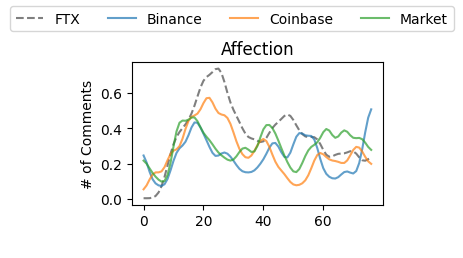

Binance - Lag 3 (xcorr: 0.62)
Coinbase - Lag 3 (xcorr: 0.78)
Market - Lag 6 (xcorr: 0.45)


<Figure size 640x480 with 0 Axes>

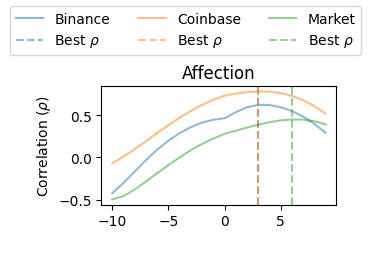

Binance - Lag 7 (xcorr: 0.96)
Coinbase - Lag 1 (xcorr: 0.98)
Market - Lag 8 (xcorr: 0.96)


<Figure size 640x480 with 0 Axes>

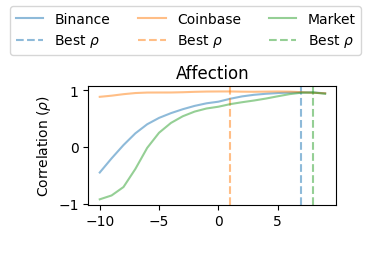

In [33]:
affection_dict = plotter_indiv_comparison(df_dict, title='Affection', ylabel='# of Comments', legend=True)
corrplot(smoothed_dict['Affection'], title='Affection', ylabel=r'Correlation ($\rho$)', legend=True)
corrplot(smoothed_ndays_dict['Affection'], title='Affection', ylabel=r'Correlation ($\rho$)', legend=True)

<Figure size 640x480 with 0 Axes>

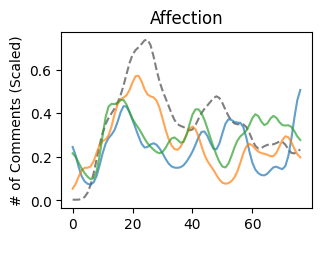

Binance - Lag 3 (xcorr: 0.62)
Coinbase - Lag 3 (xcorr: 0.78)
Market - Lag 6 (xcorr: 0.45)


<Figure size 640x480 with 0 Axes>

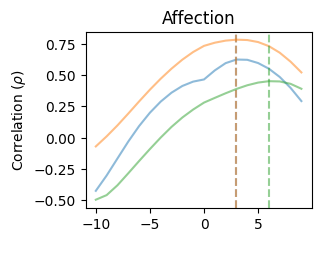

Binance - Lag 7 (xcorr: 0.96)
Coinbase - Lag 1 (xcorr: 0.98)
Market - Lag 8 (xcorr: 0.96)


<Figure size 640x480 with 0 Axes>

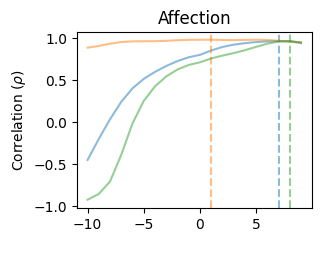

In [34]:
affection_dict = plotter_indiv_comparison(df_dict, title='Affection', ylabel='# of Comments (Scaled)')
corrplot(smoothed_dict['Affection'], title='Affection', ylabel=r'Correlation ($\rho$)')
corrplot(smoothed_ndays_dict['Affection'], title='Affection', ylabel=r'Correlation ($\rho$)')

<Figure size 640x480 with 0 Axes>

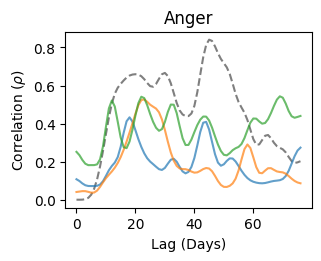

Binance - Lag 2 (xcorr: 0.76)
Coinbase - Lag 0 (xcorr: 0.50)
Market - Lag 0 (xcorr: 0.23)


<Figure size 640x480 with 0 Axes>

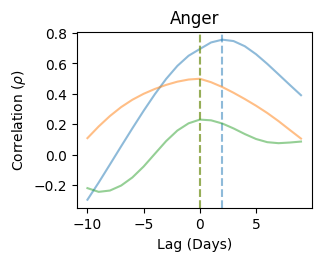

Binance - Lag -1 (xcorr: 0.89)
Coinbase - Lag -8 (xcorr: 1.00)
Market - Lag 0 (xcorr: 0.75)


<Figure size 640x480 with 0 Axes>

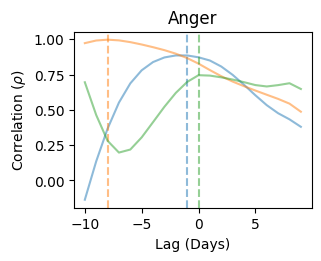

In [36]:
anger_dict = plotter_indiv_comparison(df_dict, title='Anger', ylabel=r'Correlation ($\rho$)', xlabel = 'Lag (Days)')
corrplot(smoothed_dict['Anger'], title='Anger', ylabel=r'Correlation ($\rho$)', xlabel = 'Lag (Days)')
corrplot(smoothed_ndays_dict['Anger'], title='Anger', ylabel=r'Correlation ($\rho$)', xlabel = 'Lag (Days)')

<Figure size 640x480 with 0 Axes>

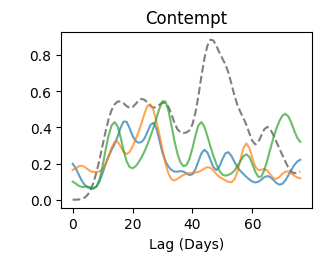

Binance - Lag 1 (xcorr: 0.52)
Coinbase - Lag 0 (xcorr: 0.18)
Market - Lag 1 (xcorr: 0.26)


<Figure size 640x480 with 0 Axes>

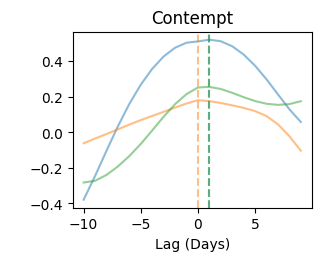

Binance - Lag -2 (xcorr: 0.98)
Coinbase - Lag -2 (xcorr: 0.83)
Market - Lag 1 (xcorr: 0.78)


<Figure size 640x480 with 0 Axes>

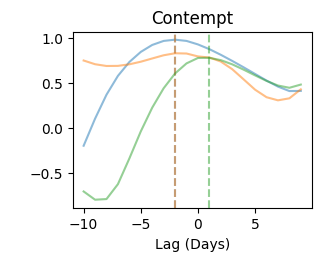

In [35]:
contempt_dict = plotter_indiv_comparison(df_dict, title='Contempt', xlabel = 'Lag (Days)')
corrplot(smoothed_dict['Contempt'], title='Contempt', xlabel = 'Lag (Days)')
corrplot(smoothed_ndays_dict['Contempt'], title='Contempt', xlabel = 'Lag (Days)')

<Figure size 640x480 with 0 Axes>

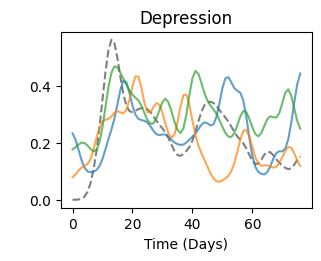

Binance - Lag -4 (xcorr: 0.69)
Coinbase - Lag 1 (xcorr: 0.43)
Market - Lag -1 (xcorr: 0.65)


<Figure size 640x480 with 0 Axes>

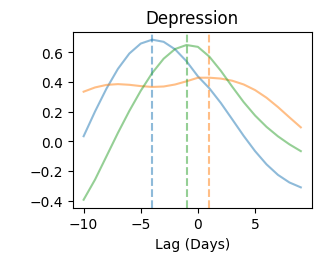

Binance - Lag -4 (xcorr: 1.00)
Coinbase - Lag -8 (xcorr: 0.90)
Market - Lag -2 (xcorr: 0.98)


<Figure size 640x480 with 0 Axes>

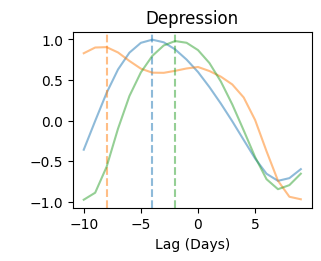

In [37]:
depression_dict = plotter_indiv_comparison(df_dict, title='Depression', xlabel = 'Time (Days)')
corrplot(smoothed_dict['Depression'], title='Depression', xlabel = 'Lag (Days)')
corrplot(smoothed_ndays_dict['Depression'], title='Depression', xlabel = 'Lag (Days)')

<Figure size 640x480 with 0 Axes>

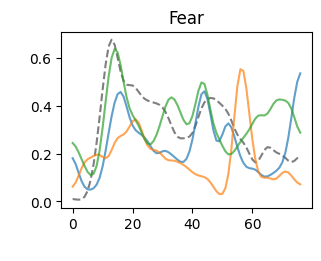

Binance - Lag -2 (xcorr: 0.61)
Coinbase - Lag -7 (xcorr: 0.42)
Market - Lag -1 (xcorr: 0.56)


<Figure size 640x480 with 0 Axes>

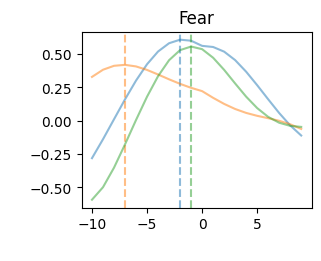

Binance - Lag -2 (xcorr: 0.98)
Coinbase - Lag -7 (xcorr: 0.96)
Market - Lag -1 (xcorr: 0.93)


<Figure size 640x480 with 0 Axes>

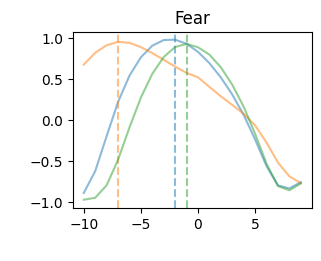

In [391]:
fear_dict = plotter_indiv_comparison(df_dict, title='Fear')
corrplot(smoothed_dict['Fear'], title='Fear')
corrplot(smoothed_ndays_dict['Fear'], title='Fear')

<Figure size 640x480 with 0 Axes>

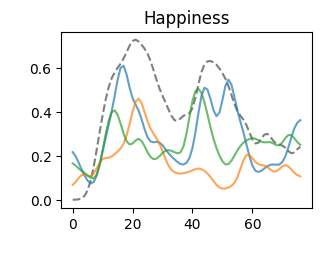

Binance - Lag 1 (xcorr: 0.74)
Coinbase - Lag 0 (xcorr: 0.55)
Market - Lag 4 (xcorr: 0.53)


<Figure size 640x480 with 0 Axes>

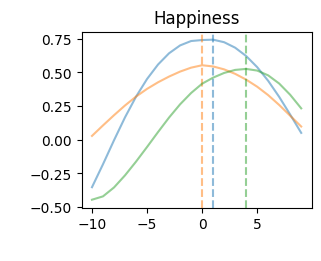

Binance - Lag 1 (xcorr: 0.88)
Coinbase - Lag -9 (xcorr: 0.97)
Market - Lag 7 (xcorr: 0.83)


<Figure size 640x480 with 0 Axes>

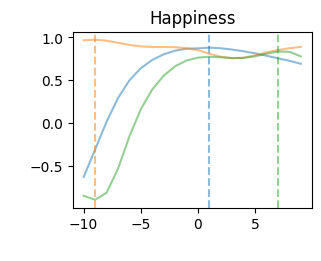

In [39]:
happiness_dict = plotter_indiv_comparison(df_dict, title='Happiness')
corrplot(smoothed_dict['Happiness'], title='Happiness')
corrplot(smoothed_ndays_dict['Happiness'], title='Happiness')

<Figure size 640x480 with 0 Axes>

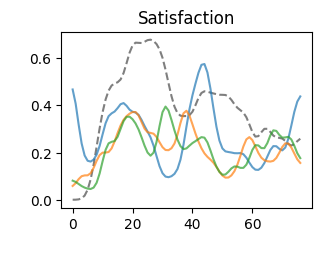

Binance - Lag 8 (xcorr: 0.45)
Coinbase - Lag 4 (xcorr: 0.66)
Market - Lag -1 (xcorr: 0.61)


<Figure size 640x480 with 0 Axes>

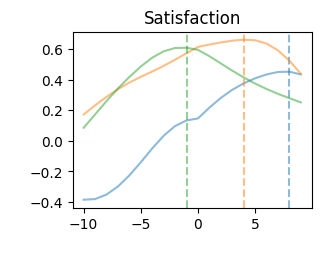

Binance - Lag 8 (xcorr: 0.92)
Coinbase - Lag 1 (xcorr: 0.95)
Market - Lag 9 (xcorr: 0.97)


<Figure size 640x480 with 0 Axes>

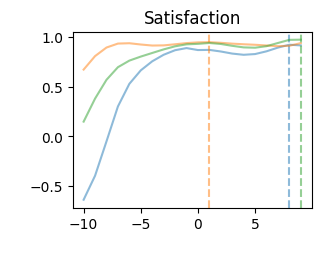

In [40]:
satisfaction_dict = plotter_indiv_comparison(df_dict, title='Satisfaction')
corrplot(smoothed_dict['Satisfaction'], title='Satisfaction')
corrplot(smoothed_ndays_dict['Satisfaction'], title='Satisfaction')